In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv("/Users/sujithrathod/krish naik /lifecycle of ml project/height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [49]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x15f4c1e50>,
 'caps': [<matplotlib.lines.Line2D at 0x15f4c23f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x15f433980>,
 'medians': [<matplotlib.lines.Line2D at 0x15f4c29f0>,
 'fliers': [<matplotlib.lines.Line2D at 0x15f4c2cf0>,
 'means': []}

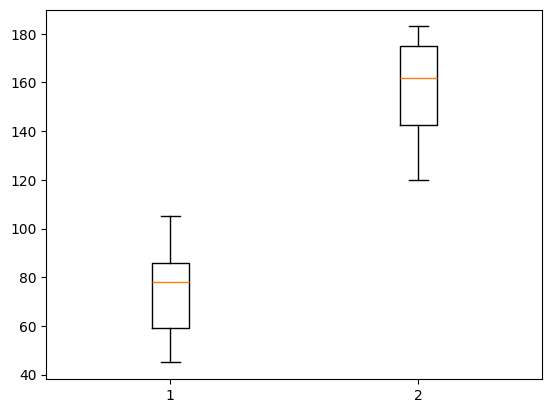

In [50]:
plt.boxplot(df)

Text(0, 0.5, 'Weight')

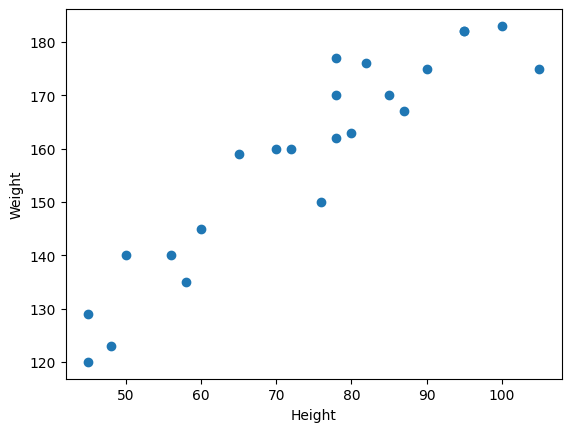

In [51]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Height")
plt.ylabel("Weight")

In [52]:
x = df[['Weight']]     
y = df['Height']

In [53]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

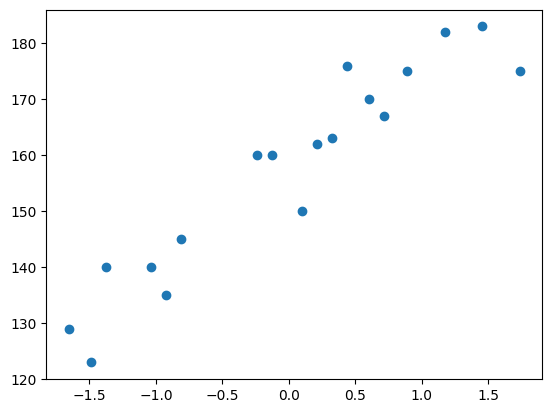

In [55]:
plt.scatter(x_train_sc,y_train)

In [56]:
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(x_train_sc,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
linreg.coef_

array([17.03440872])

In [58]:
linreg.intercept_

np.float64(157.5)

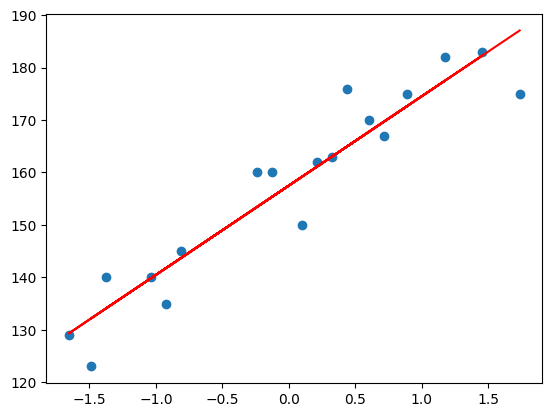

In [64]:
plt.scatter(x_train_sc,y_train)
plt.plot(x_train_sc,linreg.predict(x_train_sc),'r-')

In [66]:
y_pred = linreg.predict(x_train_sc)
y_pred

array([187.0869102 , 141.82375282, 182.27168069, 161.08467086,
       132.19329381, 177.45645118, 129.3041561 , 143.74984463,
       153.38030364, 159.15857905, 134.11938561, 139.89766102,
       155.30639545, 172.64122168, 164.93685446, 167.82599217,
       169.75208397, 163.01076266])

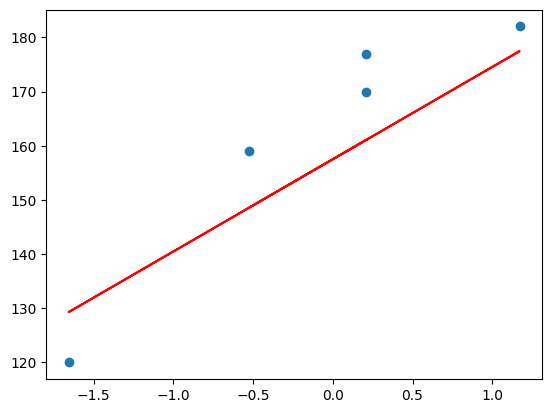

In [68]:
plt.scatter(x_test_sc,y_test)
plt.plot(x_test_sc,linreg.predict(x_test_sc),'r-')

In [72]:
y_pred_test = linreg.predict(x_test_sc)

In [73]:
# performance metrics

# mse,mae,rmse
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


In [74]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)
print(score)

0.776986986042344
